# Simple KI-Mdell for classification of sonar data

## Einstellungen

In [27]:
# Imports

import pandas as pd
import os

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import pickle
import os

In [28]:
# Configs
LOG = False
save_model = False

# Datenordner - eine Ebene höher als "dev"
import os
base_path = os.path.abspath(os.path.join(os.getcwd(), '../../../data'))

# Model
MAX_DEPTH = 4
model_save_path = os.path.abspath(os.path.join(os.getcwd(), "../../models/sonar_model_v2.pkl"))


## Trainingsdaten laden

In [29]:

import glob
import os
import pandas as pd
# Daten einlesen
data_frames = []
search_pattern = os.path.join(base_path, '**/*.csv')
csv_files = glob.glob(search_pattern, recursive=True)

print(f"Gefundene CSV-Dateien: {len(csv_files)}")

for file_path in csv_files:
    df = pd.read_csv(file_path, sep=';')                # Einlesen der CSV-Dateien, Trennzeichen ist Semikolon
    data_frames.append(df)

if data_frames:
    # Zusammenfügen zu einem einzigen DataFrame
    full_df = pd.concat(data_frames, ignore_index=True)

    # Filtern der Spalten: Wir wollen 'class_name', 'Frequency' und alle 'S_...' Spalten
    amplitude_cols = [col for col in full_df.columns if col.startswith('S_')]
    selected_cols = ['class_name', 'Frequency'] + amplitude_cols
    final_df = full_df[selected_cols]

    # Anzeigen der ersten Zeilen und der Größe des DataFrames
    print(f"Form des DataFrames: {final_df.shape}")
    display(final_df.head())
else:
    print("Keine CSV-Dateien gefunden!")


Gefundene CSV-Dateien: 12
Form des DataFrames: (300, 402)


,class_name,Frequency,S_0,S_1,S_2,S_3,S_4,S_5,S_6,S_7,...,S_390,S_391,S_392,S_393,S_394,S_395,S_396,S_397,S_398,S_399
0,Gravel,low,136,199,226,256,261,252,244,240,...,204.0,192.0,178.0,159.0,144.0,131.0,129.0,137.0,146.0,156.0
1,Gravel,high,432,350,581,947,933,1157,2477,3735,...,61.0,61.0,52.0,34.0,21.0,18.0,17.0,16.0,13.0,8.0
2,Gravel,low,136,200,226,255,262,251,243,239,...,32.0,24.0,21.0,20.0,29.0,43.0,66.0,90.0,117.0,138.0
3,Gravel,high,440,356,581,982,999,1175,2403,3552,...,36.0,27.0,21.0,27.0,31.0,33.0,40.0,34.0,22.0,20.0
4,Gravel,low,136,199,225,255,261,251,243,239,...,169.0,163.0,148.0,125.0,104.0,91.0,84.0,84.0,88.0,91.0


### Ausgabe vo 20 Zeitreihen pro klasse in ein Diagramm

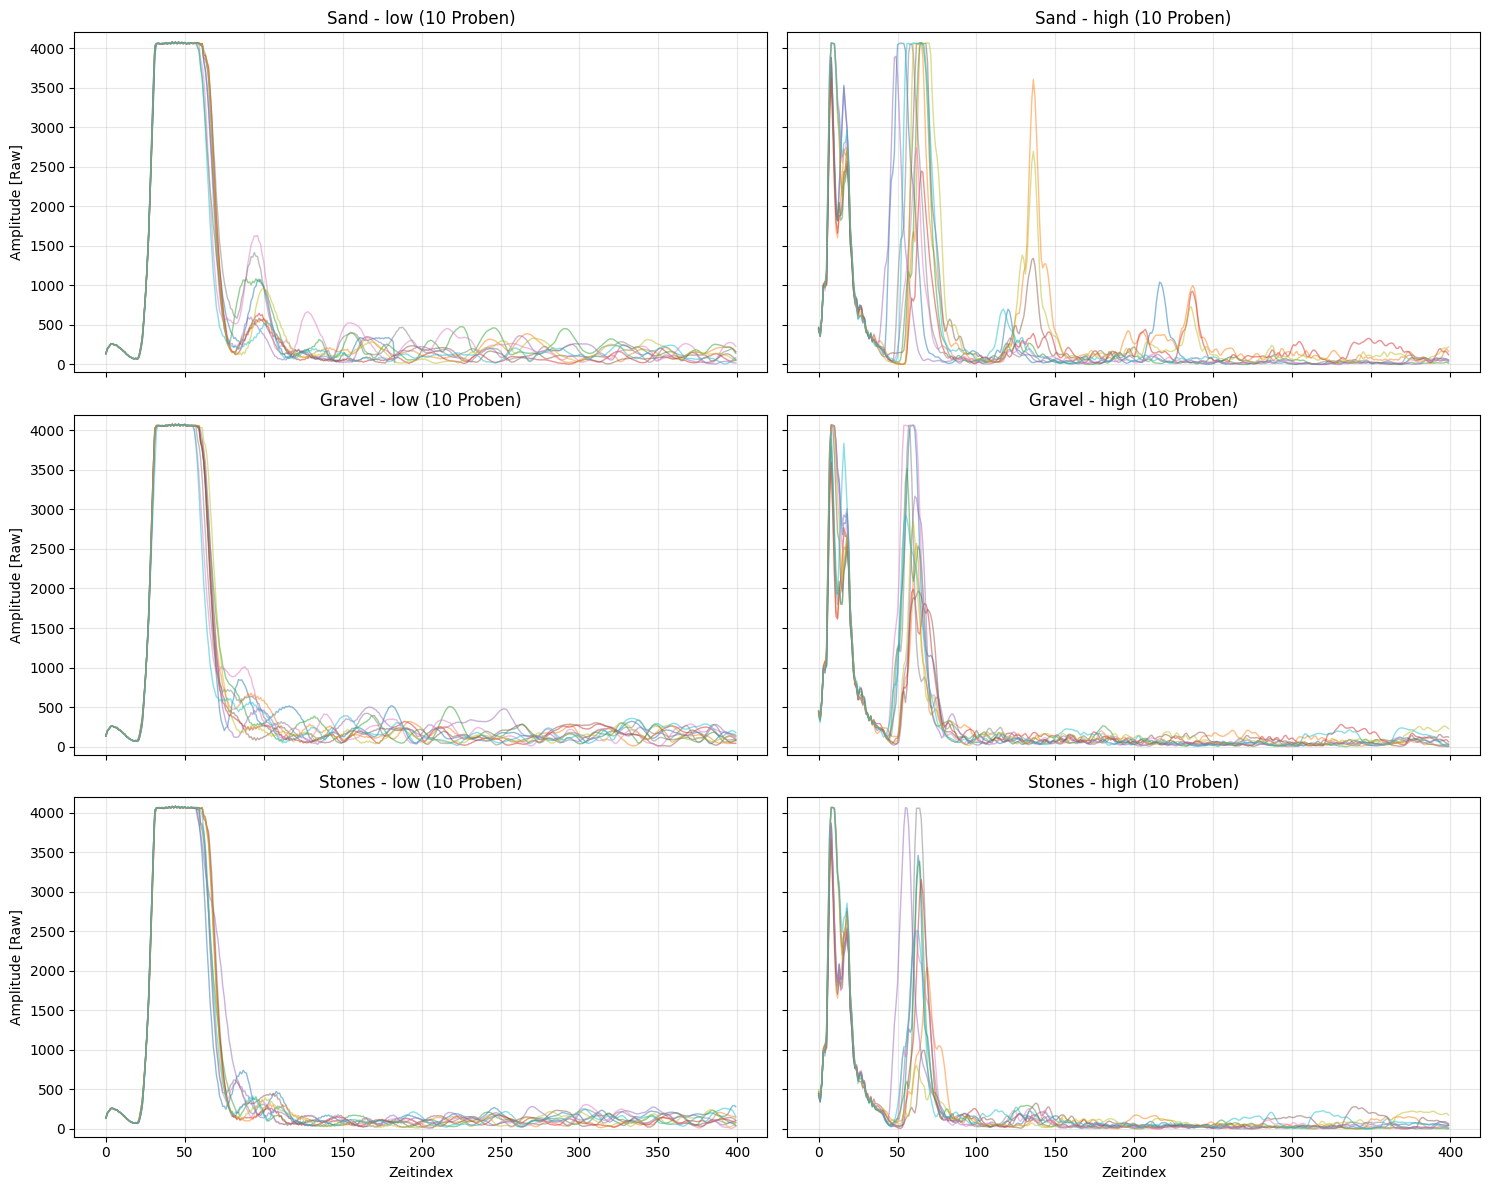

In [41]:
# Eindeutige Klassen finden
classes = ['Sand', 'Gravel', 'Stones']
frequencies = ['low', 'high']               # Definierte Reihenfolg
num_classes = len(classes)
num_freqs = len(frequencies)

# Subplots erstellen: Zeilen = Klassen, Spalten = Frequenzen
fig, axes = plt.subplots(num_classes, num_freqs, figsize=(15, 4*num_classes), sharex=True, sharey='row')

# Wenn es nur eine Klasse gibt, ist axes ein 1D Array, wir machen es 2D für konsistente Indizierung
if num_classes == 1:
    axes = np.array([axes])

for i, class_name in enumerate(classes):
    for j, freq in enumerate(frequencies):
        ax = axes[i, j]
        
        # Daten filtern für spezifische Klasse und Frequenz
        subset = final_df[(final_df['class_name'] == class_name) & (final_df['Frequency'] == freq)]
        
        n_samples = min(10, len(subset))
        
        if n_samples > 0:
            # Zufällige Auswahl
            sampled_data = subset.sample(n_samples, random_state=42)
            
            # 1. Rohdaten holen (als Float)
            result = sampled_data.drop(columns=['class_name', 'Frequency']).values.astype(float)
            
            if LOG == True:
                # 2. Direkt in dB umrechnen 
                amplitudes = np.clip(20 * np.log10(np.clip(result / 4095.0, 1e-9, 1.0)), -80, 0)
                y_min, y_max = -85, 5
            else:
                # Linear belassen (bspw. 0 bis 4095)
                amplitudes = result
                y_min, y_max = -100, 4200
            
            # Plotten
            for row in amplitudes:
                ax.plot(row, alpha=0.5, linewidth=1)
                
            # Y-Achse anpassen
            ax.set_ylim(y_min, y_max)
            ax.set_title(f'{class_name} - {freq} ({n_samples} Proben)')
        else:
            ax.set_title(f'{class_name} - {freq} (Keine Daten)')
        
        ax.grid(True, alpha=0.3)
        
        # Y-Label nur in der ersten Spalte
        if j == 0:
            if LOG == True:
                ax.set_ylabel('Amplitude [dBFS]')
            else:
                ax.set_ylabel('Amplitude [Raw]')
        
        # X-Label nur in der letzten Zeile
        if i == num_classes - 1:
            ax.set_xlabel('Zeitindex')

plt.tight_layout()
plt.show()

## Algorithmus zur Klassifikation 


### Datenvorbereitung


In [31]:
import numpy as np

# Extraktion der High- und Low-Frequency Daten
df_high = final_df[final_df['Frequency'].str.lower() == 'high'].reset_index(drop=True)
df_low = final_df[final_df['Frequency'].str.lower() == 'low'].reset_index(drop=True)

# Sicherstellen, dass beide gleich lang sind (falls eine Messung fehlte)
min_len = min(len(df_high), len(df_low))
df_high = df_high.iloc[:min_len]
df_low = df_low.iloc[:min_len]

# Amplituden für High und Low zusammenführen
amplitude_cols = [c for c in final_df.columns if c.startswith('S_')]
feature_cols_high = [f"{c}_high" for c in amplitude_cols]
feature_cols_low = [f"{c}_low" for c in amplitude_cols]
feature_cols = feature_cols_high + feature_cols_low

# Arrays verknüpfen (sehr schnell, verhindert Fragmentation Warnings)
X_temp = np.hstack([df_high[amplitude_cols].values, df_low[amplitude_cols].values])

# Zuerst das kombinierte DataFrame aufbauen
combined_df = pd.DataFrame(X_temp, columns=feature_cols)
combined_df.insert(0, 'class_name', df_high['class_name'].values)

print("Shape des kombinierten DataFrames:", combined_df.shape)
display(combined_df.head())

Shape des kombinierten DataFrames: (150, 801)


,class_name,S_0_high,S_1_high,S_2_high,S_3_high,S_4_high,S_5_high,S_6_high,S_7_high,S_8_high,...,S_390_low,S_391_low,S_392_low,S_393_low,S_394_low,S_395_low,S_396_low,S_397_low,S_398_low,S_399_low
0,Gravel,432.0,350.0,581.0,947.0,933.0,1157.0,2477.0,3735.0,4062.0,...,204.0,192.0,178.0,159.0,144.0,131.0,129.0,137.0,146.0,156.0
1,Gravel,440.0,356.0,581.0,982.0,999.0,1175.0,2403.0,3552.0,4021.0,...,32.0,24.0,21.0,20.0,29.0,43.0,66.0,90.0,117.0,138.0
2,Gravel,441.0,354.0,580.0,989.0,998.0,1081.0,2243.0,3405.0,3850.0,...,169.0,163.0,148.0,125.0,104.0,91.0,84.0,84.0,88.0,91.0
3,Gravel,443.0,358.0,585.0,956.0,945.0,1196.0,2530.0,3760.0,4068.0,...,119.0,138.0,151.0,161.0,167.0,169.0,168.0,155.0,133.0,101.0
4,Gravel,441.0,353.0,583.0,987.0,1000.0,1062.0,2182.0,3351.0,3804.0,...,96.0,113.0,137.0,166.0,199.0,225.0,241.0,258.0,262.0,257.0


### Modell Definition 

In [32]:
# X und y aus dem kombinierten DataFrame auslesen
X = combined_df[feature_cols].values
y = combined_df['class_name'].values

print(f"\nFeature Matrix Shape: {X.shape} (Samples x Features)")

# Labels kodieren
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Random Forest Classifier erstellen
clf = RandomForestClassifier(n_estimators=100, max_depth=MAX_DEPTH, random_state=42)



Feature Matrix Shape: (150, 800) (Samples x Features)


### Training 

In [33]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Trainingsdaten Shape:", X_train.shape)
print("Testdaten Shape:", X_test.shape)

# Modell trainieren
clf.fit(X_train, y_train)

# Modell Evaluation AUSSCHLIESSLICH auf dem Testdatensatz
y_pred = clf.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Trainingsdaten Shape: (120, 800)
Testdaten Shape: (30, 800)



Classification Report (Test Set):
              precision    recall  f1-score   support

      Gravel       0.83      1.00      0.91        10
        Sand       1.00      0.80      0.89        10
      Stones       0.90      0.90      0.90        10

    accuracy                           0.90        30
   macro avg       0.91      0.90      0.90        30
weighted avg       0.91      0.90      0.90        30



#### Bewertung

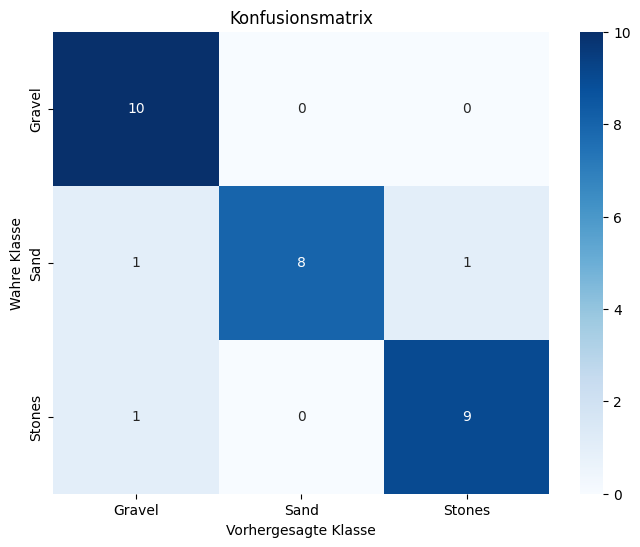

In [34]:
# A) Konfusionsmatrix

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Wahre Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.title('Konfusionsmatrix')
plt.show()


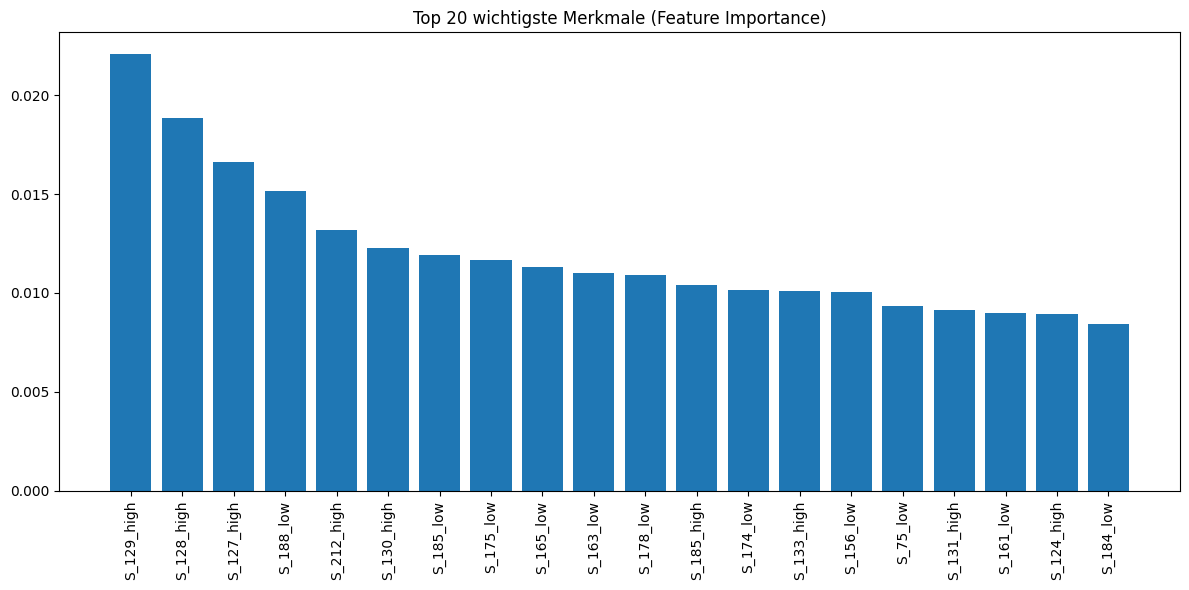

In [35]:
# B) Feature Importance (Was ist wichtig?)

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:20] # Top 20

plt.figure(figsize=(12, 6))
plt.title("Top 20 wichtigste Merkmale (Feature Importance)")
plt.bar(range(20), importances[indices], align="center")
plt.xticks(range(20), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()



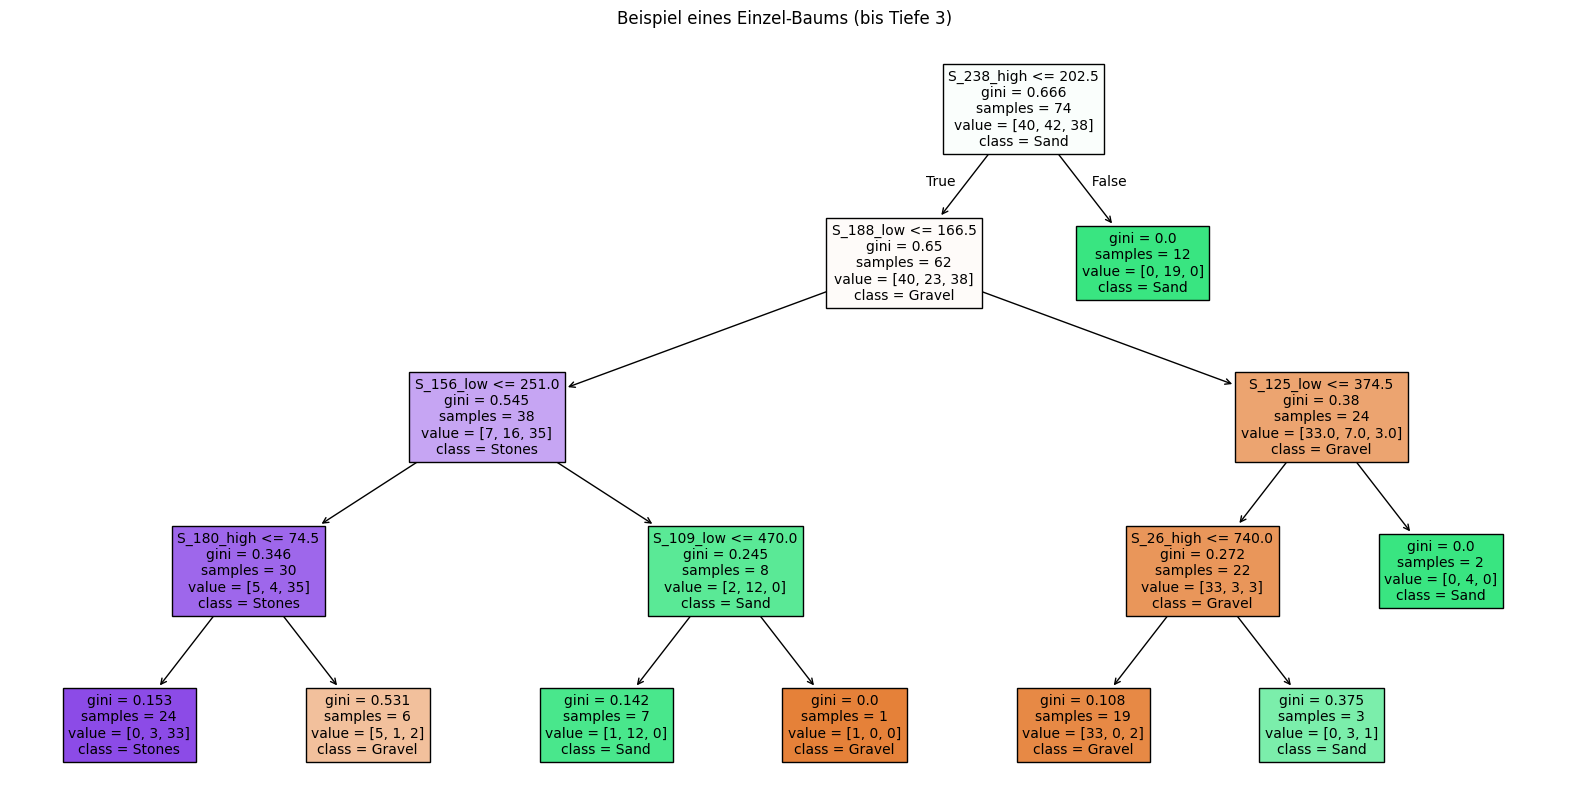

In [36]:
# C) Entscheidungsbaum visualisieren (Einer aus dem Wald)

plt.figure(figsize=(20, 10))
# Wir begrenzen die Tiefe in der Grafik, damit man noch etwas lesen kann
plot_tree(clf.estimators_[0], feature_names=feature_cols, class_names=le.classes_, filled=True, max_depth=MAX_DEPTH , fontsize=10)
plt.title("Beispiel eines Einzel-Baums (bis Tiefe 3)")
plt.show()

### Speichern 

In [37]:
if save_model:
    # Ordner erstellen, falls er nicht existiert
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

    # Modell speichern
    with open(save_path, 'wb') as f:
        pickle.dump(clf, f)
    print(f"✅ Modell erfolgreich gespeichert: {model_save_path}")
else:
    print(f"Modell nicht gespeichert: {model_save_path}")
    

Modell nicht gespeichert: c:\Users\samso\OneDrive\Dokumente\Uni\Semester 9\sonar_mpa\dev\models\sonar_model_v2.pkl
